This notebook exists to quantify fidelity metrics for the balanced homodyne simulation, as well as some qualitative tests. These are a few sections:

1. Packages, Basic Helper Functions and QuTiP initialization
2. Timing Jitter Analysis
3. Phase Jitter Analysis
4. Inferring Temporal Mode and Marginals
5. Wigner Function Reconstruction

# Setup
Here, we have packages, helper functions and some initialization functions to reduce time later on. If you already have QuTiP installed, you can skip the next cell.

In [1]:
!pip install qutip

In [2]:
import numpy as np
import qutip as qt
import scipy as sp
from scipy import integrate, ndimage, linalg, interpolate
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from math import comb, sqrt, pi
from matplotlib import colors
from numpy import random
from skimage.transform import radon, iradon


rng = random.default_rng()

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

In [3]:
def invtrans_sample(cdf, xvals, Nx, Ny):
    '''
        Draws a sample from a probability density fn with cumulative cdf
            using numpy.interp for efficiency.

          - cdf (array): array representing the cumulative distribution of P(x)
          - xvals (array): x values corresponding to cdf(xvals)
          - Nx (int): length of horizontal array
          - Ny (int): length of vertical array

        Returns:
            (array): Nx x Ny array
    '''
    # Generate uniform random number on [0,1)
    u = np.random.rand(Nx, Ny)
    # invert cdf and interpolate to find result
    sample = np.interp(u, cdf, xvals)
    return sample


def generate_basis(y, t):
    '''
        Genenerate an orthonormal basis for the homodyne trace with y as its first element.

      - y: Physical mode
      - t: Time array over which y is defined
    '''
    N = len(y)
    M = np.argmax(np.abs(y)) #location of max of mode
    # Define initial detector basis modes as instants of time

    # Ensure every degree of freedom is occupied
    x = np.zeros([N,N])
    for k in range(M):
        x[k][k+1] = 1
    for k in range(M,N):
        x[k][k] = 1
    x[:,0] = y

    q,r = np.linalg.qr(x)
    q = q.transpose() # allows us to index modes as modes[i]

    # Ensure first mode is of same sign as input mode. If it isn't, the integrated quadrature sample will be negative.
    if np.dot(q[0], y) < 0:
        q[0] = -q[0]

    # Correct normalization: integrate along axis=1 and take sqrt
    norms_squared = integrate.trapezoid(q**2, x=t, axis=1)
    norms = np.sqrt(norms_squared)
    # Reshape norms for broadcasting across all columns of q
    q = q / norms[:, np.newaxis]
    q[1] = q[1]/np.sqrt(2)
    q[-1] = q[-1]/np.sqrt(2)

    return q

def gen_photocurrent(modes,cdf,cdf_bg,xvec,Ntraces,scl = 1):
    '''
        Simulate N time domain trace from a homodyne detector.

      - modes: a set of orthonormal modes from generate_basis()
      - cdf: the cumulative distribution corresponding to the quantum state
      - cdf_bg: the background state cdf. Normally this is the vacuum but could be thermal
      - Ntraces: The number of traces to generate
      - scl: can scale the homodyne photocurrent by this value. Usually 1.
    '''
    Npts = len(modes) # Number of points in each photocurrent trace


    q0_coeffs_mode0 = invtrans_sample(cdf, xvec, Ntraces, 1) # One sample drawn from cdf
    q0_coeffs_other_modes = invtrans_sample(cdf_bg, xvec, Ntraces, Npts - 1) # Rest drawn from background

    q0 = np.concatenate((q0_coeffs_mode0, q0_coeffs_other_modes), axis=1) # Shape (Ntraces, Npts)


    ihd = np.matmul(q0, modes) # Generate traces as a matrix

    return ihd*scl

def W_to_marge(W, theta, xvec):
    '''
        Generate a marginal distribution of the given Wigner function at
        phase angle theta using the Radon transform.

        Returns an array of the same length as xvec, effectively mapping
        the rotated projection back onto the original simulation grid.

      - W: Input wigner function (square 2D array)
      - theta: Angle along which to integrate (in radians)
      - xvec: array over which W is defined in one dimension
    '''
    dx = xvec[1] - xvec[0]

    sinogram = radon(W, theta=[np.degrees(theta)], circle=False)
    projection = sinogram[:, 0]

    N_proj = len(projection)
    x_proj = (np.arange(N_proj) - N_proj // 2) * dx

    marge = np.interp(xvec, x_proj, projection, left=0, right=0)

    norm = integrate.simpson(marge, x=xvec)
    if norm > 1e-15:
        marge /= norm

    return marge


def marge_to_cdf(marge):
    '''
        Takes marginal and returns cdf of same length

        Often, we bypass this as it only works for 1 marginal while we usually
            want to integrate N at once.
    '''
    cdf_unnorm = integrate.cumulative_trapezoid(marge, initial=0)
    cdf = cdf_unnorm/cdf_unnorm[-1] # ensure normalization
    return cdf


def state_to_objects(state, x, p, theta = 0):
    '''
        Takes a QuTiP state and returns wigner function, marginal and cdf
      - state: QuTiP state
      - x: array of x values
      - p: array of p values
      - theta: phase angle for marginal
    '''
    W = qt.wigner(state,x,p)
    marge = W_to_marge(W, theta, x)
    cdf = marge_to_cdf(marge)
    return W, marge, cdf

In [4]:
# COMMON TEMPORAL MODES

def square(t, a, b):
    '''
        Return an L^2 normalized rectangular wave with positive value
            between a and b, 0 otherwise

          - t : time array
          - a : start of wave
          - b : end of wave
    '''
    if b <= a:
        raise ValueError("Wave must end after it starts: a < b")
    y = np.zeros_like(t)
    for i in range(len(t)):
        if t[i] >= a and t[i] <= b:
            y[i] = 1
    return y/np.sqrt(b-a)

def gaussian_env(t, mu, sigma):
    y = np.exp(-(t-mu)**2/(2*sigma**2))
    return y/np.sqrt(integrate.simpson(y**2, x=t))

In [5]:
# BASIC SETUP: QUANTUM STATES

dim = 20 # dimension of fock space
x = np.linspace(-8,8,801)
p = np.linspace(-8,8,801)

bg = qt.fock(dim, 0) # vacuum state
bg_W, bg_marge, bg_cdf = state_to_objects(bg, x, p, 0)

co = qt.coherent(dim, 2) # basic coherent state
co_W, co_marge, co_cdf = state_to_objects(co, x, p, 0)

fock1 = qt.fock(dim, 1) # 1-photon fock state
fock1_W, fock1_marge, fock1_cdf = state_to_objects(fock1, x, p, 0)

fock2 = qt.fock(dim, 2) # 2-photon fock state
fock2_W, fock2_marge, fock2_cdf = state_to_objects(fock2, x, p, 0)

cat = (qt.coherent(dim, 2) + qt.coherent(dim, -2)).unit() # cat state w/ alpha = 2
cat_W, cat_marge, cat_cdf = state_to_objects(cat, x, p, 0)

sqvac= qt.squeeze(dim, 0.5)*qt.fock(dim, 0) # squeezed vacuum, xi = 1
sqvac_W, sqvac_marge, sqvac_cdf = state_to_objects(sqvac, x, p, 0)

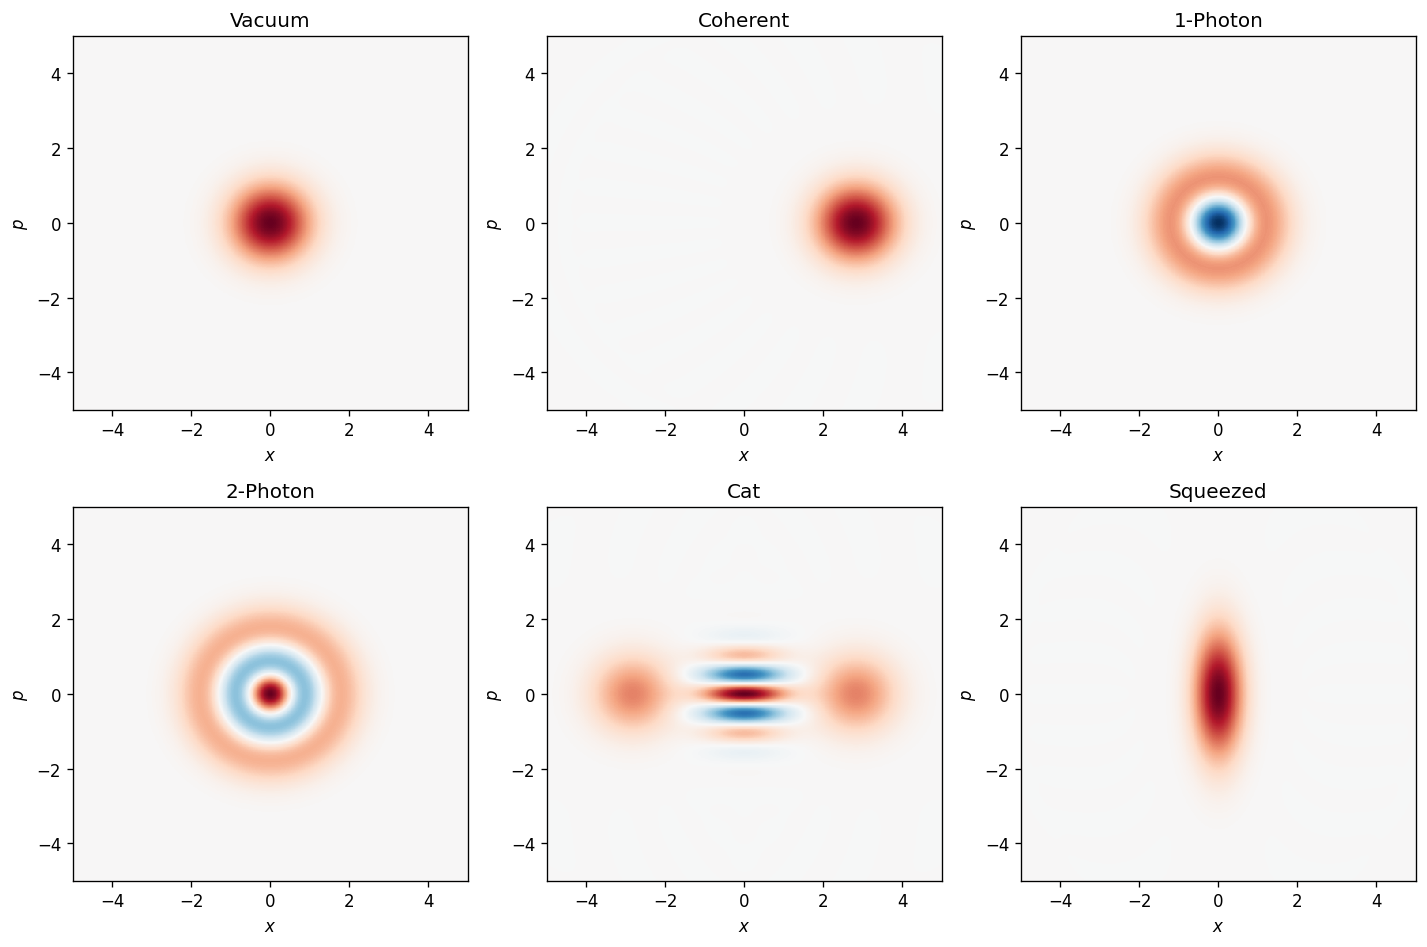

In [6]:
# Plot wigner functions to make sure everything is working correctly

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax = ax.flatten()

wigners = {'Vacuum'     : bg_W,
           'Coherent'   : co_W,
           '1-Photon'   : fock1_W,
           '2-Photon'   : fock2_W,
           'Cat'        : cat_W,
           'Squeezed'   : sqvac_W}

for i, title in enumerate(wigners):
    vmax = np.max(np.abs(wigners[title]))
    ax[i].pcolormesh(x, p, wigners[title], vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    ax[i].set_title(title)
    ax[i].set_xlim(-5,5)
    ax[i].set_ylim(-5,5)
    ax[i].set_xlabel('$x$')
    ax[i].set_ylabel('$p$')

plt.tight_layout() # if plot is glitching, comment this out.

plt.show()

In [7]:
# BASIC SETUP: TEMPORAL MODES

t = np.linspace(-20,20,401) # time domain for trace

gen_mode = gaussian_env(t, 0, 1)
modes = generate_basis(gen_mode, t)

# Timing Jitter
In our case, timing jitter causes the generating modes to be shifted by some time $\tau$. We assume this noise to be normally distributed.

As all of the modes are shifted by the same $\tau$, the effect of timing jitter is equivalent to jitter in the measuring mode - that is, instead of integrating

$$\int_{-\infty}^\infty h(t)\sum_{i=1}^np_i\phi_i(t)dt,$$

we integrate (noting the linearity and finiteness of the integral)

$$\int_{-\infty}^\infty h(t-\tau)\sum_{i=1}^np_i\phi_i(t)dt = \sum_{i=1}^np_i \int_{-\infty}^\infty h(t-\tau)\phi_i(t)dt$$

for a normally distributed sampling of $\tau$ values. We note that this is also a convolution integral, which illustrates our reasoning that we could swap the delay from $\phi$ to $h$.

In [8]:
# Define States in a manner easy to access

quantum_states_data = {
    'Vacuum State': {'state_object': bg, 'marge': bg_marge, 'cdf': bg_cdf, 'label': 'Vacuum'},
    'Coherent State': {'state_object': co, 'marge': co_marge, 'cdf': co_cdf, 'label': 'Coherent'},
    'Fock 1 State': {'state_object': fock1, 'marge': fock1_marge, 'cdf': fock1_cdf, 'label': 'Fock 1-Photon'},
    'Fock 2 State': {'state_object': fock2, 'marge': fock2_marge, 'cdf': fock2_cdf, 'label': 'Fock 2-Photon'},
    'Cat State': {'state_object': cat, 'marge': cat_marge, 'cdf': cat_cdf, 'label': 'Cat State'},
    'Squeezed Vacuum State': {'state_object': sqvac, 'marge': sqvac_marge, 'cdf': sqvac_cdf, 'label': 'Squeezed Vacuum'}
}

In [9]:
# Compute fidelities for each state.

Nsamps = 10000
Nsigs = 51
sigmas = np.linspace(0, 10, Nsigs)

bins_hist = 250
hist_range = (np.min(x), np.max(x))

# Redefine gen_mode in case it has been redefined in memory
gen_mode = gaussian_env(t, 0, 1)
modes = generate_basis(gen_mode, t)

fidelity_results = {}

for state_name, state_data in quantum_states_data.items():
    state_marge = state_data['marge']
    state_cdf = state_data['cdf']
    state_label = state_data['label']

    current_state_fidelities = []
    print(f"\nCalculating fidelity for {state_label}...")

    for i, sig in enumerate(sigmas):
        tau_vals = rng.normal(0, sig, size = Nsamps)

        meas_modes = np.zeros((Nsamps, len(t)))
        for j, tau in enumerate(tau_vals):
            meas_modes[j,:] = gaussian_env(t, tau, 1)

        # Generate photocurrent traces
        simulated_currents = gen_photocurrent(modes, state_cdf, bg_cdf, x, Nsamps)

        # Integrate traces against the jittered 'measuring modes'
        y_integrated = integrate.trapezoid(simulated_currents * meas_modes, x=t, axis=1)

        # Generate quadrature histogram
        exp_pdf_simulated, bin_edges = np.histogram(y_integrated, bins=bins_hist,
                                                    range=hist_range, density=True)

        # Bin theoretical marginal
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        dx_hist = bin_centers[1] - bin_centers[0]
        theory_pdf_interp = np.interp(bin_centers, x, state_marge, left=0, right=0)

        # Compute Bhattacharyya Coefficient (np.maximum acts element-wise)
        current_simulated_fidelity = np.sum(np.sqrt(np.maximum(0, exp_pdf_simulated) * np.maximum(0, theory_pdf_interp))) * dx_hist
        current_state_fidelities.append(current_simulated_fidelity)

        print(f'\r    Processed {i+1}/{len(sigmas)} jitter stddevs for {state_label}. Current stddev = {sig:.2f}', end='')

    fidelity_results[state_label] = np.array(current_state_fidelities)

print('\n\nFidelity calculations for all states and jitter distributions complete.')


Calculating fidelity for Vacuum...
  Processed 51/51 jitter stddevs for Vacuum. Current stddev = 10.00
Calculating fidelity for Coherent...
  Processed 51/51 jitter stddevs for Coherent. Current stddev = 10.00
Calculating fidelity for Fock 1-Photon...
  Processed 51/51 jitter stddevs for Fock 1-Photon. Current stddev = 10.00
Calculating fidelity for Fock 2-Photon...
  Processed 51/51 jitter stddevs for Fock 2-Photon. Current stddev = 10.00
Calculating fidelity for Cat State...
  Processed 51/51 jitter stddevs for Cat State. Current stddev = 10.00
Calculating fidelity for Squeezed Vacuum...
  Processed 51/51 jitter stddevs for Squeezed Vacuum. Current stddev = 10.00

Fidelity calculations for all states and jitter distributions complete.


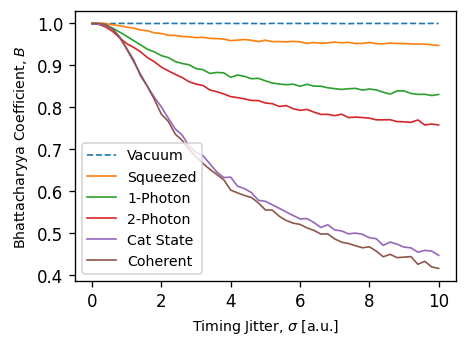

In [10]:
plt.figure(figsize=(4, 3))

plt.plot(sigmas, fidelity_results['Vacuum'], linestyle='--',
         label='Vacuum', linewidth=1) #plot vacuum to ensure it is equal to 1 always
plt.plot(sigmas, fidelity_results['Squeezed Vacuum'], linestyle='-',
         label='Squeezed', linewidth=1)
plt.plot(sigmas, fidelity_results['Fock 1-Photon'], linestyle='-',
         label='1-Photon', linewidth=1)
plt.plot(sigmas, fidelity_results['Fock 2-Photon'], linestyle='-',
         label='2-Photon', linewidth=1)
plt.plot(sigmas, fidelity_results['Cat State'], linestyle='-',
         label='Cat State', linewidth=1)
plt.plot(sigmas, fidelity_results['Coherent'], linestyle='-',
         label='Coherent', linewidth=1)



plt.xlabel(r'Timing Jitter, $\sigma$ [a.u.]', fontsize=8.5)
plt.ylabel('Bhattacharyya Coefficient, $B$', fontsize=8.5)
plt.legend(loc='lower left', fontsize=8.5)
plt.tight_layout()
plt.show()

# Phase Jitter
Phase jitter, which we define as an error $\delta \theta$ in the angle along which we integrate our Wigner function to obtain our marginal. We begin our simulation by pre-computing the marginal of the given Wigner function for a number of angles (usually upwards of 1000) from $-\pi\to\pi$ using the Radon transform. Because phase jitter does not affect rotationally symmetric states, we redefine `quantum_states_data` to avoid unnecessary computation.

Furthermore, to reduce computation time, we directly sample the marginals rather than producing a trace and integrating it. As there is no timing jitter, this should not affect results.

In [11]:
# Redefine gen_mode in case it has been redefined in memory
gen_mode = gaussian_env(t, 0, 1)
modes = generate_basis(gen_mode, t)
meas_mode_ideal = gen_mode

# Select only non-symmetric states
phase_quantum_states_data = {
    'Squeezed Vacuum State': {'state_object': sqvac, 'marge': sqvac_marge, 'cdf': sqvac_cdf, 'label': 'Squeezed'},
    'Cat State': {'state_object': cat, 'marge': cat_marge, 'cdf': cat_cdf, 'label': 'Cat'},
    'Coherent State': {'state_object': co, 'marge': co_marge, 'cdf': co_cdf, 'label': 'Coherent'}
}

In [12]:
# Pre-compute marginals for all states
N_lookup = 1000
lookup_thetas = np.linspace(-np.pi, np.pi, N_lookup)
lookup_thetas_deg = np.degrees(lookup_thetas)

precomputed_cdfs = {}
precomputed_ideals = {}

print("Pre-computing Radon transforms for all states...")

for state_name, state_data in phase_quantum_states_data.items():
    # Get base Wigner at theta=0
    W_base, _, _ = state_to_objects(state_data['state_object'], x, p, 0)

    # Compute marginals for all angles
    sinogram = radon(W_base, theta=lookup_thetas_deg, circle=False)

    # Interpolate output to x
    dx = x[1] - x[0]
    r_rows = sinogram.shape[0]
    x_radon = (np.arange(r_rows) - r_rows // 2) * dx

    interpol = interpolate.interp1d(x_radon, sinogram, axis=0,
                                        kind='linear', bounds_error=False, fill_value=0)
    marginals_aligned = interpol(x)

    # Renormalize marginals
    areas = integrate.simpson(marginals_aligned, dx=dx, axis=0)
    areas[areas < 1e-10] = 1.0 # Avoid div/0
    pdfs = marginals_aligned / areas[np.newaxis, :]

    # Compute CDFs
    cdfs = integrate.cumulative_trapezoid(pdfs, x, axis=0, initial=0)
    cdfs /= cdfs[-1, :] # Ensure they end at exactly 1.0

    precomputed_cdfs[state_data['label']] = cdfs

    # Store ideal marginal for later use
    precomputed_ideals[state_data['label']] = state_data['marge']
    print(f'    Completed {state_name}')

print("Pre-computation complete.")

Pre-computing Radon transforms for all states...
Completed Squeezed Vacuum State
Completed Cat State
Completed Coherent State
Pre-computation complete.


In [13]:
Nsamps_per_sigma = 10000 # samples/jitter
Nsigs = 50 # number of jitter stddevs
sigmas_dth = np.linspace(0, np.pi, Nsigs)

bins_hist = 100 # bins for Bhattacharyya Coefficient Computation
hist_range = (np.min(x), np.max(x))
dx = x[1] - x[0]

fidelity_results_phase_jitter_dist = {}


for state_name, state_data in phase_quantum_states_data.items():
    state_label = state_data['label']
    lookup_table = precomputed_cdfs[state_label]
    ideal_marginal = precomputed_ideals[state_label]

    current_state_fidelities = np.zeros(Nsigs)
    print(f"\nSimulating {state_label}...")

    for i, sig_dth in enumerate(sigmas_dth):
        # Sample N random phase shifts from Gaussian
        dth_vals = rng.normal(0, sig_dth, size=Nsamps_per_sigma)

        # Wrap jitter to [-pi,pi]
        dth_vals = (dth_vals + np.pi) % (2 * np.pi) - np.pi

        # Find nearest index in the lookup table
        idx_step = lookup_thetas[1] - lookup_thetas[0]
        indices = np.round((dth_vals - lookup_thetas[0]) / idx_step).astype(int)
        indices = np.clip(indices, 0, N_lookup - 1)

        # ITS
        u_vals = rng.random(Nsamps_per_sigma)

        batch_cdfs = lookup_table[:, indices]

        samples = np.zeros(Nsamps_per_sigma)
        for k in range(Nsamps_per_sigma):
            samples[k] = np.interp(u_vals[k], batch_cdfs[:, k], x)

        # Histogram the samples
        exp_pdf, bin_edges = np.histogram(samples, bins=bins_hist,
                                          range=hist_range, density=True)

        # Bin theoretical marginal
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        dx_hist = bin_centers[1] - bin_centers[0]
        theory_pdf = np.interp(bin_centers, x, ideal_marginal, left=0, right=0)

        # Compute Bhattacharyya Coefficient
        fid = np.sum(np.sqrt(np.maximum(0, exp_pdf) * np.maximum(0, theory_pdf))) * dx_hist
        current_state_fidelities[i] = fid

        print(f'\r    {i+1}/{Nsigs} ({sig_dth:.2f} rad)', end='')

    fidelity_results_phase_jitter_dist[state_label] = current_state_fidelities

print('\ndone')


Simulating Squeezed...
    50/50 (3.14 rad)
Simulating Cat...
    50/50 (3.14 rad)
Simulating Coherent...
    50/50 (3.14 rad)
done


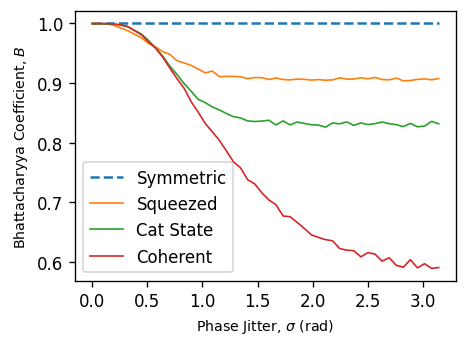

In [14]:
plt.figure(figsize=(4,3))

plt.plot(sigmas_dth, np.ones_like(sigmas_dth), linestyle='--', label='Symmetric')
plt.plot(sigmas_dth, fidelity_results_phase_jitter_dist['Squeezed'],
         linestyle='-', label='Squeezed', linewidth=1)
plt.plot(sigmas_dth, fidelity_results_phase_jitter_dist['Cat'],
         linestyle='-', label='Cat State', linewidth=1)
plt.plot(sigmas_dth, fidelity_results_phase_jitter_dist['Coherent'],
         linestyle='-', label='Coherent', linewidth=1)



plt.xlabel(r'Phase Jitter, $\sigma$ (rad)', fontsize=8.5)
plt.ylabel(r'Bhattacharyya Coefficient, $B$', fontsize=8.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Inferring Modes and Marginals

Because an arbitrary state carries more variance in its quadrature than the vacuum, plotting the pointwise variance of the photocurrents will reveal the mode containing the state. Furthermore, we can infer the marginal by histogramming our output data.

In [15]:
gen_mode = gaussian_env(t, 0, 1) #play around with this!
modes = generate_basis(gen_mode, t)

Nsamps = 50000
traces_1photon = gen_photocurrent(modes, fock1_cdf, bg_cdf, x, Nsamps)
traces_vac = gen_photocurrent(modes, bg_cdf, bg_cdf, x, Nsamps)

Text(0, 0.5, 'Photocurrent Variance')

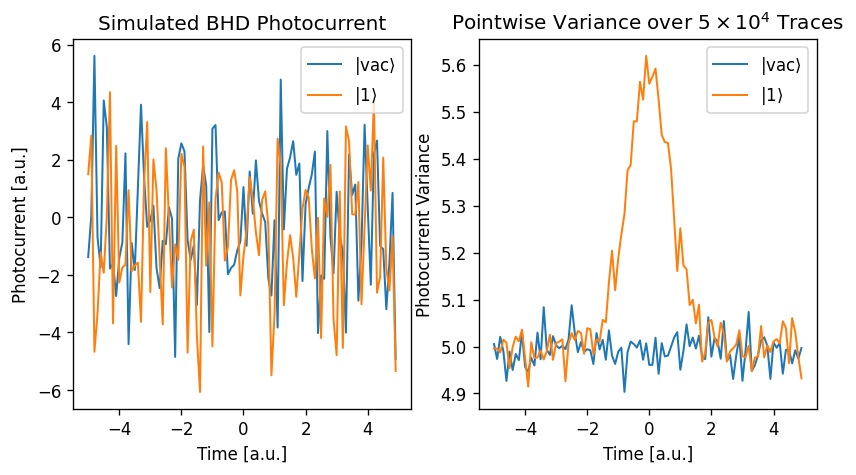

In [16]:
var_1photon = np.var(traces_1photon, axis=0)
var_vac = np.var(traces_vac, axis=0)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(t[150:250], traces_vac[21][150:250], label=r'$|$vac$\rangle$', linewidth=1.2)
ax[0].plot(t[150:250], traces_1photon[28][150:250], label=r'$|1\rangle$', linewidth=1.2)
ax[0].legend()
ax[0].set_title('Simulated BHD Photocurrent')
ax[0].set_xlabel('Time [a.u.]')
ax[0].set_ylabel('Photocurrent [a.u.]')

ax[1].plot(t[150:250], var_vac[150:250], label=r'$|$vac$\rangle$', linewidth=1.2)
ax[1].plot(t[150:250], var_1photon[150:250], label=r'$|1\rangle$', linewidth=1.2)
ax[1].legend()
ax[1].set_title(r'Pointwise Variance over $5\times10^4$ Traces')
ax[1].set_xlabel('Time [a.u.]')
ax[1].set_ylabel('Photocurrent Variance')

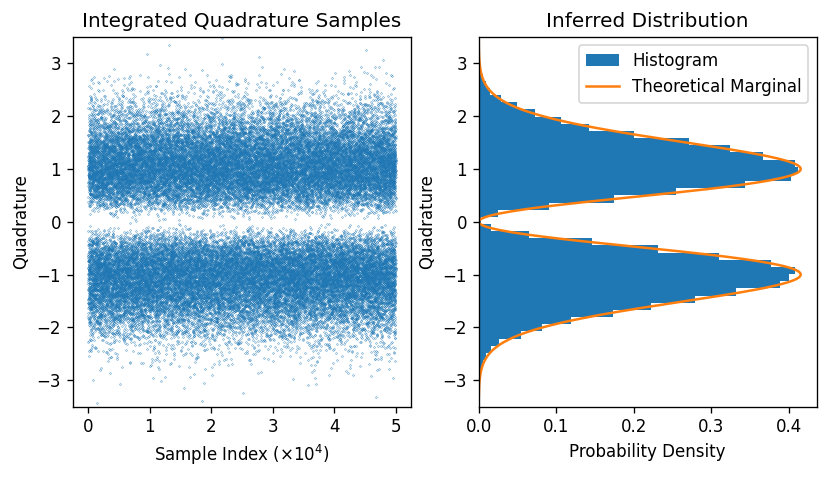

In [17]:
samples = integrate.trapezoid(traces_1photon*gen_mode, x=t, axis=1) # reconstruct quadratures

fig,ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].scatter(np.array(range(len(samples)))/10000, samples, s=0.05)
ax[0].set_ylim(-3.5,3.5)
ax[0].set_title('Integrated Quadrature Samples')
ax[0].set_ylabel('Quadrature')
ax[0].set_xlabel(r'Sample Index ($\times 10^4$)')

ax[1].hist(samples, 51, orientation='horizontal', density=True, label = 'Histogram')
ax[1].plot(fock1_marge, x, label='Theoretical Marginal')
ax[1].set_ylim(-3.5,3.5)
ax[1].set_title('Inferred Distribution')
ax[1].set_xlabel('Probability Density')
ax[1].set_ylabel('Quadrature')
ax[1].legend()

# Wigner Function Reconstruction

We recontruct a Wigner function with the inverse radon transform for a range of bad measurements. We start with perfect reconstruction, then introduce different amounts of timing jitter to the reconstruction.

Most of the following code is to resample/interpolate the wigner function and its derivative functions to the $x-$axis, as functions like `radon` and `iradon` output on arrays of different lengths.

In [18]:
state = cat
W_base, _, _ = state_to_objects(state, x, p, 0)

gen_mode = gaussian_env(t, 0, 1)
modes = generate_basis(gen_mode, t)

Nsamps = 10000
Ntheta = 61

# Prepare measurement modes for different jitters
meas_modes_sigma0 = np.zeros((Nsamps, len(t)))
meas_modes_sigma0[:,:] = gaussian_env(t, 0, 1)

tau_vals_sigma1 = rng.normal(0, 1, size=Nsamps)
meas_modes_sigma1 = np.zeros((Nsamps, len(t)))
for i, tau in enumerate(tau_vals_sigma1):
    meas_modes_sigma1[i,:] = gaussian_env(t, tau, 1)

tau_vals_sigma2 = rng.normal(0, 2, size=Nsamps)
meas_modes_sigma2 = np.zeros((Nsamps, len(t)))
for i, tau in enumerate(tau_vals_sigma2):
    meas_modes_sigma2[i,:] = gaussian_env(t, tau, 1)

tau_vals_sigma5 = rng.normal(0, 5, size=Nsamps)
meas_modes_sigma5 = np.zeros((Nsamps, len(t)))
for i, tau in enumerate(tau_vals_sigma5):
    meas_modes_sigma5[i,:] = gaussian_env(t, tau, 1)


# Pre-calculate theoretical marginals (sinograms) and CDFs
thetas = np.linspace(0, np.pi, Ntheta)

sinogram = radon(W_base, theta=np.degrees(thetas), circle=False)

radon_rows = sinogram.shape[0]
x_radon = (np.arange(radon_rows) - radon_rows // 2) * dx

areas = integrate.simpson(sinogram, dx=dx, axis=0)
areas[areas < 1e-10] = 1.0 # Avoid division by zero
marginals = sinogram / areas[np.newaxis, :]

f_interp = interpolate.interp1d(x_radon, marginals, axis=0, kind='cubic',
                                bounds_error=False, fill_value=0.0)
marginals = f_interp(x)

# Compute CDFs
print('Calculating CDFs...')
cdfs = integrate.cumulative_trapezoid(marginals, x, axis=0, initial=0)
cdfs /= cdfs[-1, :] # Normalize the last point to exactly 1.0


jitter_conditions = {
    'sigma0': meas_modes_sigma0,
    'sigma1': meas_modes_sigma1,
    'sigma2': meas_modes_sigma2,
    'sigma5': meas_modes_sigma5
}

reconstructed_wigners = {}

# Define target shape for resampling reconstructed Wigner functions
target_shape_W = (len(p), len(x))

for jitter_label, meas_modes_current in jitter_conditions.items():
    print(f"\nProcessing jitter: {jitter_label}")
    sinograms = np.zeros((bins_hist, Ntheta))

    for i in range(Ntheta):
        print(f'\r    Simulating angle {i+1}/{Ntheta}. theta = {thetas[i]:.2f}', end='')

        cdf_col = cdfs[:, i] # Get the CDF for the current angle

        # Generate simulated photocurrent traces using the CDF for the current angle
        simulated_currents = gen_photocurrent(modes, cdf_col, bg_cdf, x, Nsamps)

        # Integrate the simulated traces against the current set of jittered measurement modes
        y_integrated = integrate.simpson(simulated_currents * meas_modes_current, x=t, axis=1)

        # Generate histogram from integrated simulated traces
        hist, _ = np.histogram(y_integrated, bins=bins_hist, range=hist_range, density=True)
        sinograms[:,i] = hist

    print('\n    Reconstructing Wigner function...')
    W_reconstructed = iradon(sinograms, theta=np.degrees(thetas), filter_name='ramp')

    # Resample the reconstructed Wigner function to the target shape immediately
    scale_factor_p = target_shape_W[0] / W_reconstructed.shape[0]
    scale_factor_x = target_shape_W[1] / W_reconstructed.shape[1]
    W_reconstructed = zoom(W_reconstructed, (scale_factor_p, scale_factor_x), order=3)

    reconstructed_wigners[jitter_label] = W_reconstructed

print("\ndone")

Calculating CDFs...

Processing jitter: sigma0
    Simulating angle 61/61. theta = 3.14
    Reconstructing Wigner function...

Processing jitter: sigma1
    Simulating angle 61/61. theta = 3.14
    Reconstructing Wigner function...

Processing jitter: sigma2
    Simulating angle 61/61. theta = 3.14
    Reconstructing Wigner function...

Processing jitter: sigma5
    Simulating angle 61/61. theta = 3.14
    Reconstructing Wigner function...

done


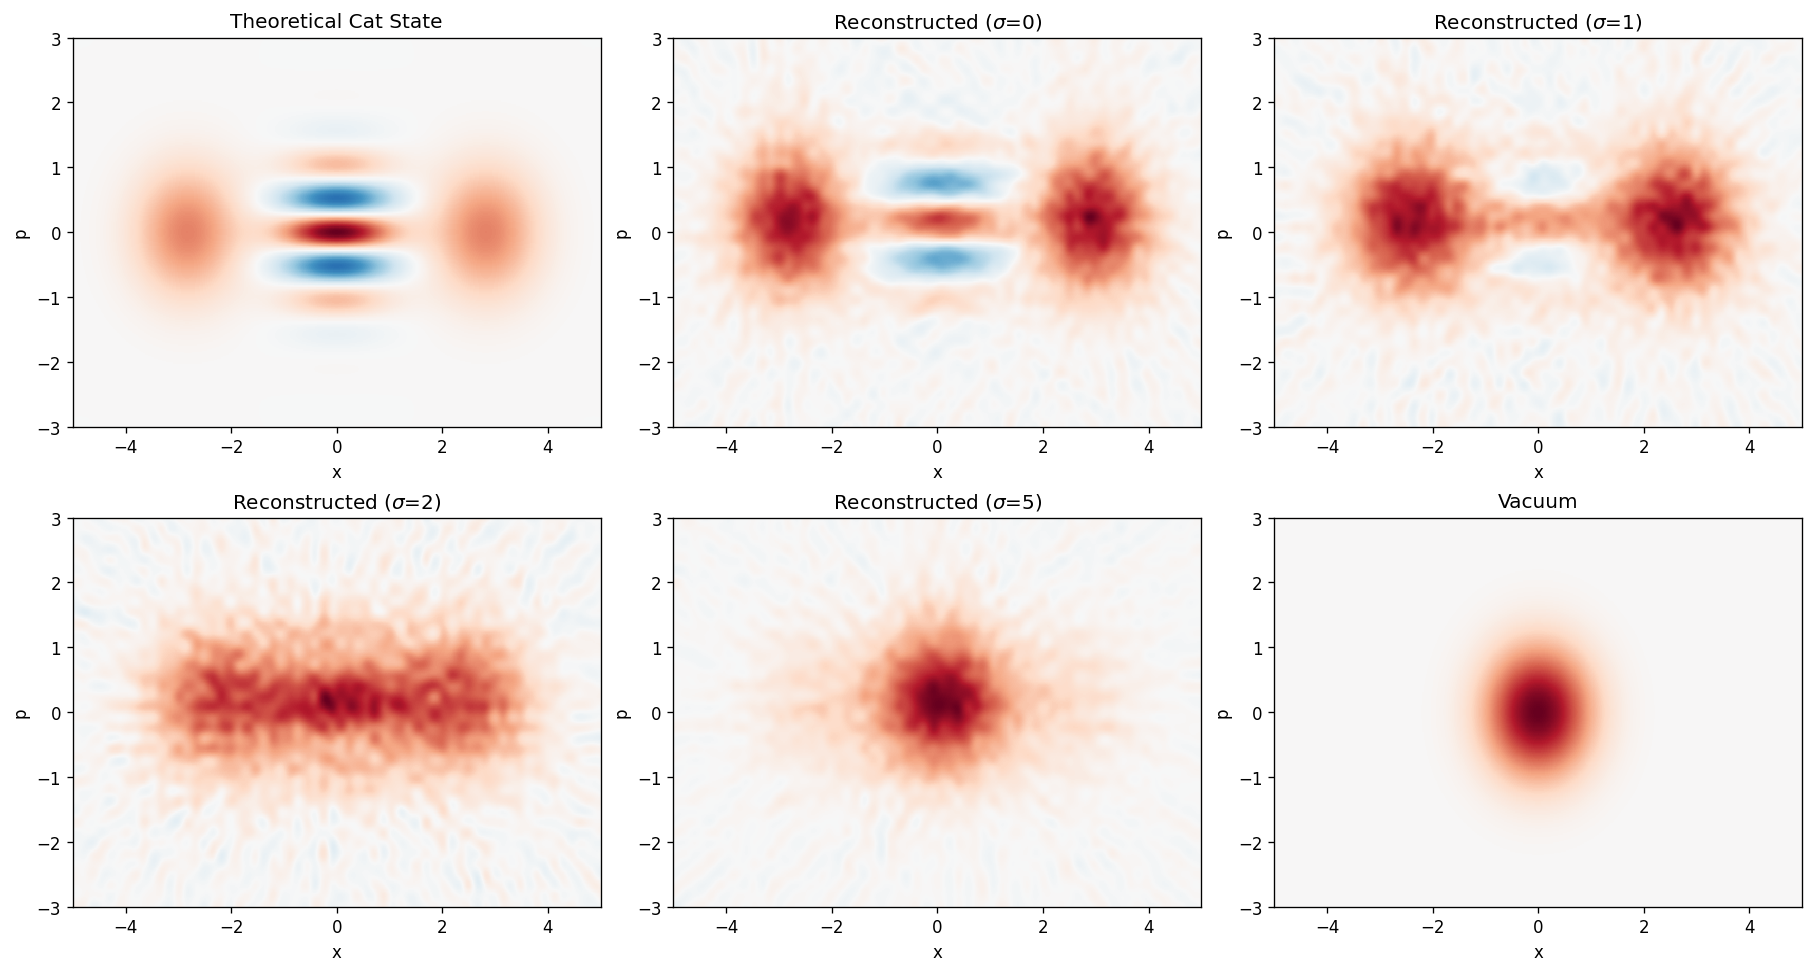

In [19]:
wigners = {
    'Theoretical Cat State': W_base,
    r'Reconstructed ($\sigma$=0)': reconstructed_wigners['sigma0'],
    r'Reconstructed ($\sigma$=1)': reconstructed_wigners['sigma1'],
    r'Reconstructed ($\sigma$=2)': reconstructed_wigners['sigma2'],
    r'Reconstructed ($\sigma$=5)': reconstructed_wigners['sigma5'],
    'Vacuum': bg_W
}

fig, ax = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
ax = ax.flatten()

for i, (label, W) in enumerate(wigners.items()):
    vmax = np.max(np.abs(W))
    ax[i].pcolormesh(x, p, W, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='nearest')

    ax[i].set_title(label)
    ax[i].set_xlabel("x")
    ax[i].set_ylabel("p")
    ax[i].set_xlim(-5, 5)
    ax[i].set_ylim(-3, 3)

plt.show()